In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../")

from src.pipeline.data_loader import load_data
from src.pipeline.preprocessor import preprocess_pipeline
from src.features.feature_engineering import run_feature_engineering
from src.config import PROCESSED_DATA_FILE, TARGET_COLUMN

%matplotlib inline
sns.set_theme(style="whitegrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Load and preprocess
df = load_data()
X_train, X_test, y_train, y_test = preprocess_pipeline(df)

# Load processed and add features
processed_df = pd.read_csv(PROCESSED_DATA_FILE)
enriched_df  = run_feature_engineering(processed_df)

print(f"\n✅ Original Features  : {len(df.columns)}")
print(f"✅ Enriched Features  : {len(enriched_df.columns)}")
print(f"\nNew columns added:")
new_cols = [c for c in enriched_df.columns if c not in df.columns]
for col in new_cols:
    print(f"   ➕ {col}")

✅ Loading data from: c:\Users\HP\churn_prediction_system\data\raw\customers.csv

🧹 STARTING PREPROCESSING PIPELINE
🔧 Handling missing values...
   ✅ Missing values after fix: 0
🔧 Removed 0 duplicate rows.
🔧 Encoding categorical columns...
   ✅ Encoded: gender
   ✅ Encoded: contract_type
   ✅ Encoded: payment_method
   ✅ Encoded: internet_service
🔧 Scaling numerical columns...
   ✅ Scaler saved to: c:\Users\HP\churn_prediction_system\models\scaler.pkl

✅ Processed data saved to: c:\Users\HP\churn_prediction_system\data\processed\customers_processed.csv
🔧 Splitting data into train/test sets...
   ✅ Train size: 800 | Test size: 200

✅ PREPROCESSING COMPLETE!


⚡ STARTING FEATURE ENGINEERING
⚡ Adding RFM features...
   ✅ RFM features added!
⚡ Adding engagement features...
   ✅ Engagement features added!
⚡ Adding risk features...
   ✅ Risk features added!
⚡ Adding CLV segments...
   ✅ CLV segments added!

✅ Enriched data saved to: c:\Users\HP\churn_prediction_system\data\processed\customers

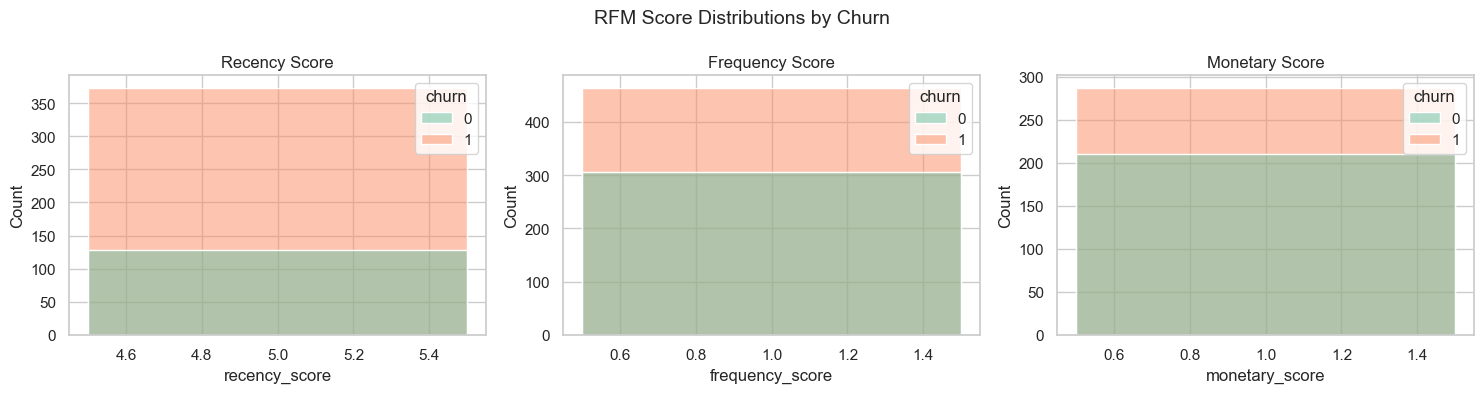

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm_cols = ["recency_score", "frequency_score", "monetary_score"]
titles   = ["Recency Score", "Frequency Score", "Monetary Score"]

for i, (col, title) in enumerate(zip(rfm_cols, titles)):
    sns.histplot(
        data=enriched_df, x=col,
        hue="churn", palette="Set2",
        kde=False,
        ax=axes[i]
    )
    axes[i].set_title(title)

plt.suptitle("RFM Score Distributions by Churn", fontsize=14)
plt.tight_layout()
plt.show()

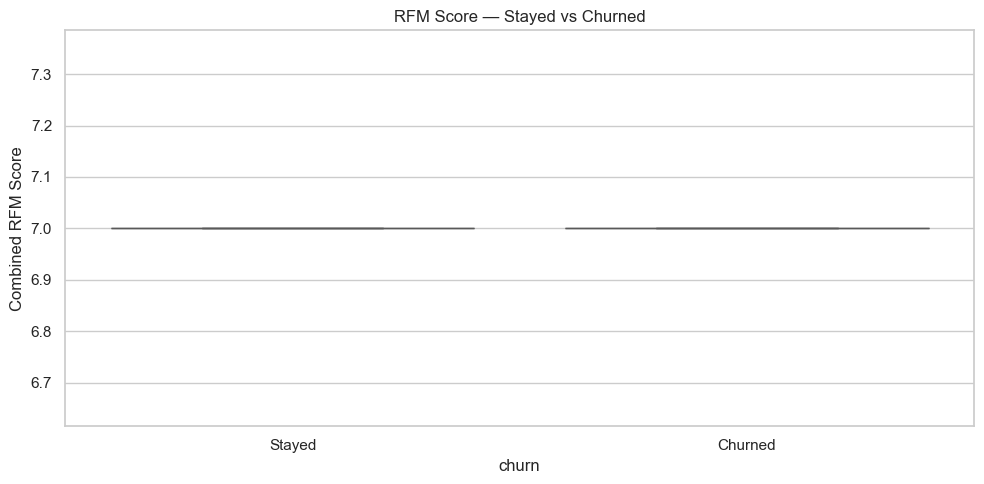

📊 RFM Score Stats:
       count  mean  std  min  25%  50%  75%  max
churn                                           
0       55.0   7.0  0.0  7.0  7.0  7.0  7.0  7.0
1      139.0   7.0  0.0  7.0  7.0  7.0  7.0  7.0


In [5]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=enriched_df,
    x="churn", y="rfm_score",
    hue="churn", legend=False,
    palette="Set2"
)
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.title("RFM Score — Stayed vs Churned")
plt.ylabel("Combined RFM Score")
plt.tight_layout()
plt.show()

# Stats
print("📊 RFM Score Stats:")
print(enriched_df.groupby("churn")["rfm_score"].describe().round(2))

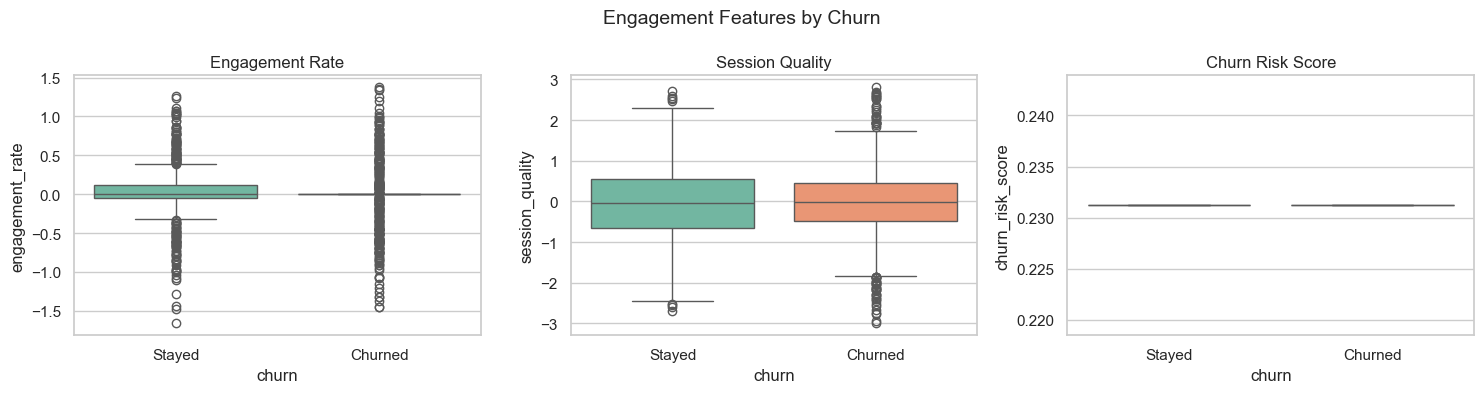

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

eng_cols = ["engagement_rate", "session_quality", "churn_risk_score"]
titles   = ["Engagement Rate", "Session Quality", "Churn Risk Score"]

for i, (col, title) in enumerate(zip(eng_cols, titles)):
    sns.boxplot(
        data=enriched_df,
        x="churn", y=col,
        hue="churn", legend=False,
        palette="Set2", ax=axes[i]
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Stayed", "Churned"])
    axes[i].set_title(title)

plt.suptitle("Engagement Features by Churn", fontsize=14)
plt.tight_layout()
plt.show()

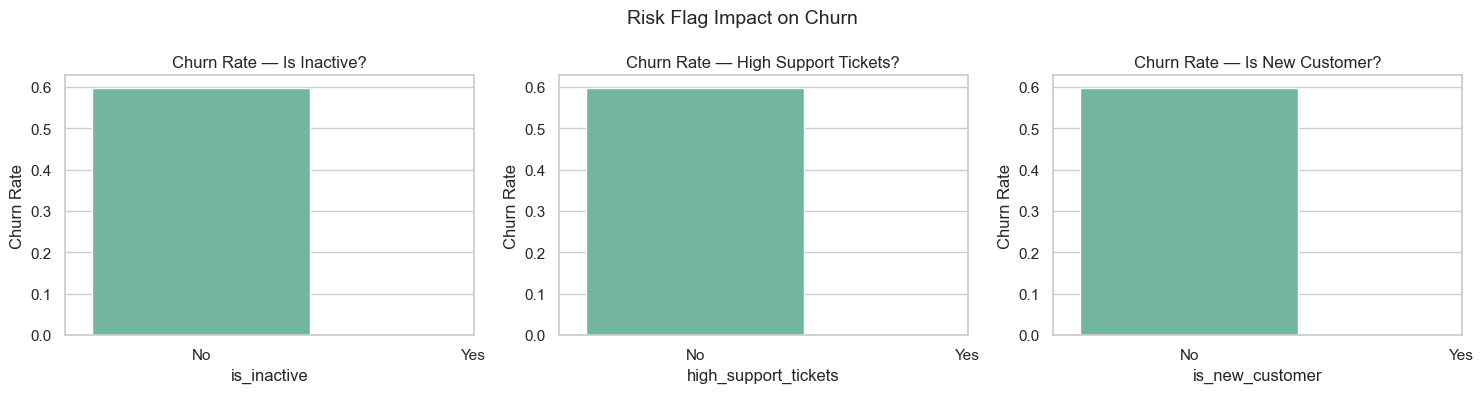

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

flag_cols = ["is_inactive", "high_support_tickets", "is_new_customer"]
titles    = ["Is Inactive?", "High Support Tickets?", "Is New Customer?"]

for i, (col, title) in enumerate(zip(flag_cols, titles)):
    churn_rate = enriched_df.groupby(col)["churn"].mean().reset_index()
    sns.barplot(
        data=churn_rate,
        x=col, y="churn",
        hue=col, legend=False,
        palette="Set2", ax=axes[i]
    )
    axes[i].set_title(f"Churn Rate — {title}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])

plt.suptitle("Risk Flag Impact on Churn", fontsize=14)
plt.tight_layout()
plt.show()

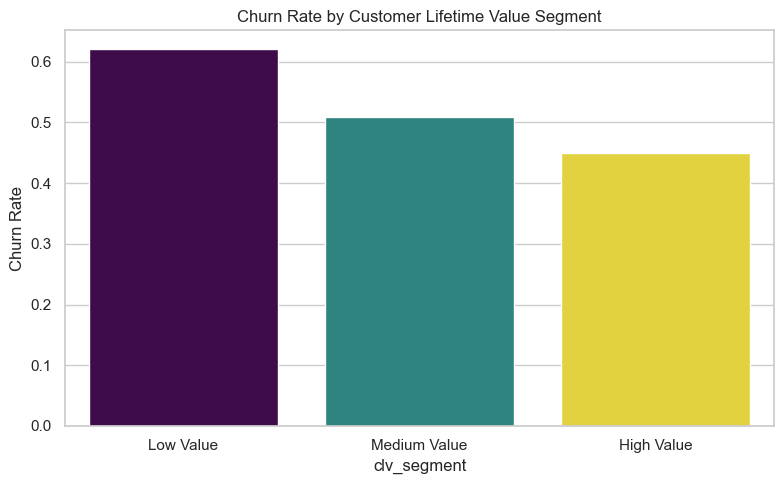

In [9]:
plt.figure(figsize=(8, 5))

clv_churn = enriched_df.groupby("clv_segment")["churn"].mean().reset_index()
sns.barplot(
    data=clv_churn,
    x="clv_segment", y="churn",
    hue="clv_segment", legend=False,
    palette="viridis"
)
plt.xticks([0, 1, 2], ["Low Value", "Medium Value", "High Value"])
plt.title("Churn Rate by Customer Lifetime Value Segment")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

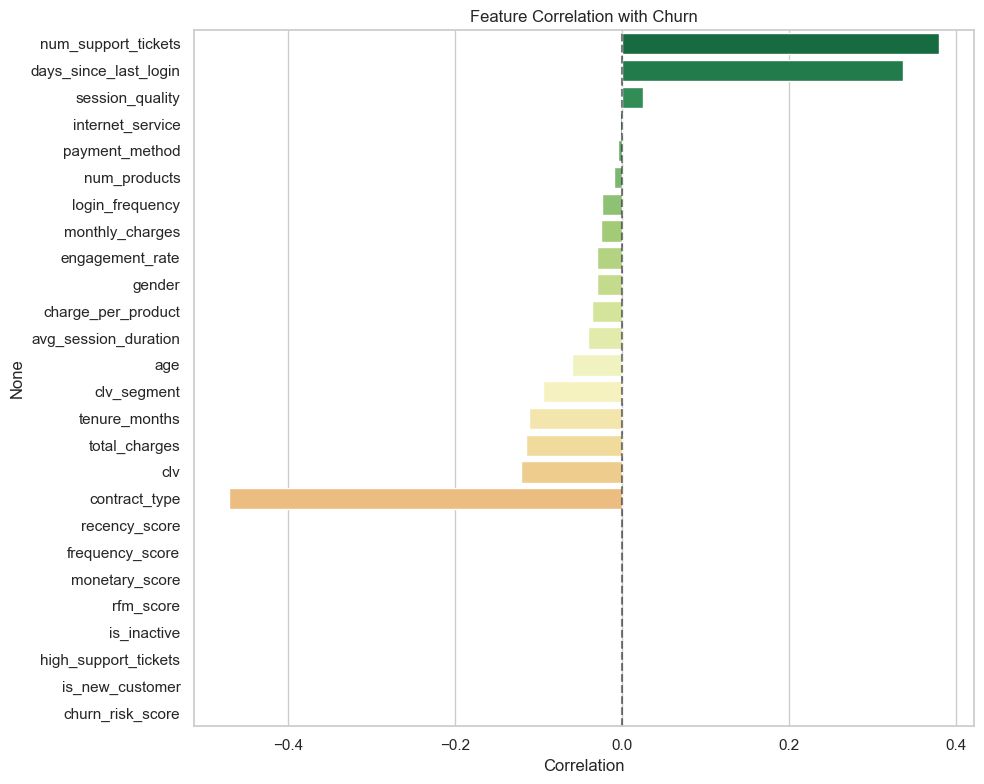


🔝 Top 5 Positive Churn Correlations:
num_support_tickets      0.379
days_since_last_login    0.337
session_quality          0.025
internet_service        -0.002
payment_method          -0.005

🔽 Top 5 Negative Churn Correlations:
rfm_score              NaN
is_inactive            NaN
high_support_tickets   NaN
is_new_customer        NaN
churn_risk_score       NaN


In [10]:
plt.figure(figsize=(10, 8))

num_df   = enriched_df.select_dtypes(include=[np.number])
corr_churn = num_df.corr()["churn"].drop("churn").sort_values(ascending=False)

sns.barplot(
    x=corr_churn.values,
    y=corr_churn.index,
    hue=corr_churn.index,
    legend=False,
    palette="RdYlGn_r"
)
plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n🔝 Top 5 Positive Churn Correlations:")
print(corr_churn.head(5).round(3).to_string())
print("\n🔽 Top 5 Negative Churn Correlations:")
print(corr_churn.tail(5).round(3).to_string())

In [11]:
print("="*55)
print("⚡ FEATURE ENGINEERING SUMMARY")
print("="*55)

print(f"\n📊 Total Features Created : {len(new_cols)}")
print(f"\n📋 New Features:")
for col in new_cols:
    print(f"   ➕ {col}")

print(f"\n🎯 Most Correlated with Churn:")
print(corr_churn.abs().sort_values(ascending=False).head(5).round(3).to_string())
print("="*55)

⚡ FEATURE ENGINEERING SUMMARY

📊 Total Features Created : 12

📋 New Features:
   ➕ recency_score
   ➕ frequency_score
   ➕ monetary_score
   ➕ rfm_score
   ➕ engagement_rate
   ➕ is_inactive
   ➕ high_support_tickets
   ➕ session_quality
   ➕ charge_per_product
   ➕ is_new_customer
   ➕ churn_risk_score
   ➕ clv_segment

🎯 Most Correlated with Churn:
contract_type            0.471
num_support_tickets      0.379
days_since_last_login    0.337
clv                      0.121
total_charges            0.115
